<a href="https://colab.research.google.com/github/arm456/Python-notebooks/blob/main/Multi_Agent_Travel_Planner.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Travel Planning Multi-Agent system**

An intelligent system that coordinates multiple specialized agents to search flights, hotels, plan itineraries, and provide personalized travel recommendations.

# **Step 1 - Start with the process to automate**


*   Search hotels and flights based on user preferences

*   Plan complete travel itineraries


*   Answer travel-related questions with deep research

*   Handle multiple queries in parallel


*   Present unified, well-formatted travel recommendation










# **Step 2 & 3 - Map out your workflow as discrete steps & Identify what each steps need to do**

*   **Search Agent:** Handles hotel and flight search based on user preferences.

*  **Itinerary Planner Agent:** Utilizes search results and research to create detailed travel plans.


## Install LangGraph

In [1]:
!pip install -U -q langgraph langchain

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.8/169.8 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.7/112.7 kB 4.7 MB/s eta 0:00:00


## Chat Model

In [2]:
# Install Required Libraries
!pip install -U -q langchain-openai

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 2.2 MB/s eta 0:00:00


In [3]:
# Import API Keys

import getpass
import os
from google.colab import userdata

try:
    api_key_from_secrets = userdata.get("OPENAI_API_KEY")
    os.environ["OPENAI_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

Enter your OpenAI API key: ··········


In [4]:
# Chat Model

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5.2",
    temperature=0.2,

    # stream_usage=True,
    # max_tokens=None,
    # timeout=None,
    # reasoning_effort="low",
    # max_retries=2,
    # api_key="...",  # If you prefer to pass api key in directly
    # base_url="...",
    # organization="...",
    # other params...
)

### Test Chat Model

In [5]:
test_msg = llm.invoke("What is Mlachine Learning? Explain with the help of an example.")

In [6]:
# Raw Response
test_msg

AIMessage(content='**Machine Learning (ML)** is a branch of Artificial Intelligence (AI) where a computer learns patterns from data and uses those patterns to make predictions or decisions **without being explicitly programmed with fixed rules** for every situation.\n\n### Key idea\nInstead of writing rules like “if X then Y,” you give the machine **examples (data)**, and it learns a **model** that can handle new, unseen cases.\n\n---\n\n## Example: Email Spam Detection\n### Goal\nDecide whether an email is **Spam** or **Not Spam**.\n\n### How ML works here\n1. **Collect data:** Thousands of emails labeled as “spam” or “not spam.”\n2. **Extract features:** The model looks at patterns such as:\n   - Words like *“free,” “win,” “urgent”*\n   - Too many links\n   - Suspicious sender address\n   - Unusual formatting or capitalization\n3. **Train a model:** The algorithm learns which patterns are common in spam vs. normal emails.\n4. **Make predictions:** For a new email it has never seen, i

In [7]:
# HumanMesage: User Query
# AIMessage: Response from AI, Response to use tool (tool calling)
# SystemMessage: System Prompt/Task the LLM should perform
# ToolMessage: Tool Execution


# tool: addition

# HumanMesage: what is 2 + 2
# AIMessage: call the tool addition
# ToolMessage: 2+2=4, return 4
# SystemMessage:

In [8]:
test_msg.response_metadata

{'token_usage': {'completion_tokens': 301,
  'prompt_tokens': 20,
  'total_tokens': 321,
  'completion_tokens_details': {'accepted_prediction_tokens': 0,
   'audio_tokens': 0,
   'reasoning_tokens': 0,
   'rejected_prediction_tokens': 0},
  'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}},
 'model_provider': 'openai',
 'model_name': 'gpt-5.2-2025-12-11',
 'system_fingerprint': None,
 'id': 'chatcmpl-DTgGkGrNhdrRWuxtKcSYyzYeRht5m',
 'service_tier': 'default',
 'finish_reason': 'stop',
 'logprobs': None}

In [9]:
# Print in Readable Format
print(test_msg.text)

**Machine Learning (ML)** is a branch of Artificial Intelligence (AI) where a computer learns patterns from data and uses those patterns to make predictions or decisions **without being explicitly programmed with fixed rules** for every situation.

### Key idea
Instead of writing rules like “if X then Y,” you give the machine **examples (data)**, and it learns a **model** that can handle new, unseen cases.

---

## Example: Email Spam Detection
### Goal
Decide whether an email is **Spam** or **Not Spam**.

### How ML works here
1. **Collect data:** Thousands of emails labeled as “spam” or “not spam.”
2. **Extract features:** The model looks at patterns such as:
   - Words like *“free,” “win,” “urgent”*
   - Too many links
   - Suspicious sender address
   - Unusual formatting or capitalization
3. **Train a model:** The algorithm learns which patterns are common in spam vs. normal emails.
4. **Make predictions:** For a new email it has never seen, it predicts:
   - **Spam** or **Not Spa

## Itinerary Agent

In [10]:
# Install Required Libraries

!pip install -q deepagents tavily-python langchain-tavily

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.7/137.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.5/48.5 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.7/508.7 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 627.5/627.5 kB 33.8 MB/s eta 0:00:00


### Web Search Tool

In [11]:
# Necessary Imports
from typing import Literal
from tavily import TavilyClient

In [12]:
from langchain.chat_models import init_chat_model
from deepagents import create_deep_agent

In [13]:
# Import API Keys
try:
    api_key_from_secrets = userdata.get("TAVILY_API_KEY")
    os.environ["TAVILY_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your Tavily API key: ")

In [14]:
# Create Internet Search vis TavilySearch

from langchain_tavily import TavilySearch

internet_search = TavilySearch(
    max_results=5,
    topic="general", # news, finance
    include_images=True,
    include_image_descriptions=True,
    search_depth="advanced",
    # include_answer=False,
    # include_raw_content=False,
    # time_range="day",
    # include_domains=None,
    # exclude_domains=None
)

In [15]:
# Test internet_search
internet_search.invoke({"query": "Top Travel attractions in Vienna"})

{'query': 'Top Travel attractions in Vienna',
 'follow_up_questions': None,
 'answer': None,
 'images': [{'url': 'https://dynamic-media-cdn.tripadvisor.com/media/photo-o/1c/2d/28/e4/wwwschoenbrunnat.jpg?w=500&h=-1&s=1',
   'title': 'THE 15 BEST Things to Do in Vienna (2026) - Must-See Attractions',
   'description': 'An expansive baroque palace with symmetrical gardens and a grand central building surrounded by lush greenery, situated in Vienna.'},
  {'url': 'https://media.timeout.com/images/106152216/image.jpg',
   'title': '16 Best Attractions in Vienna for 2025',
   'description': 'A horse-drawn carriage passes in front of the Hofburg Palace in Vienna, with its grand neoclassical architecture and green domes illuminated by bright sunlight.'},
  {'url': 'https://epepa.eu/wp-content/uploads/2018/09/gloriette-schonbrunn-vienna.jpg',
   'title': 'TOP 10 best things to do in Vienna, Austria | Epepa Travel Blog',
   'description': 'A grand, neoclassical building with ornate statues and co

### Deep Research Agent

In [16]:
# Define Model for Deep Research Agent
model = init_chat_model(model="gpt-5.2", model_provider="openai", temperature=0.2)

In [17]:
# create_deep_agent: creates a fully-configured autonomous agent capable of deep reasoning, tool use, and multi-step planning with minimal setup.

# A factory that returns a pre-wired LangChain/LangGraph agent (create_agent(...)) with a default “Deep Agent” system prompt
# plus a stack of middleware for: todos, filesystem I/O, sub-agent delegation,
# summarization/offloading, prompt-caching (Anthropic), and tool-call patching.

# middleware is a layer of logic that runs between two stages of a system to intercept, modify, or extend behavior.
# Middleware = code that runs between request and response to modify or control execution.

# https://github.com/langchain-ai/deepagents/blob/main/libs/deepagents/deepagents/graph.py

In [18]:
# "research about pharma industry in NA"

# 1. history of pharma
# 2. current players in mkt
# 3. gdp pharma in NA
# 4. current technological

In [19]:
# Itinerary Agent (Deep Research) Prompt

from deepagents import create_deep_agent

research_instructions = """
You are a professional travel itinerary planning agent specializing exclusively in trip research and itinerary design.

SCOPE AND BEHAVIOR RULES
- Respond ONLY to travel-related requests, including destinations, itineraries, activities, transportation, accommodations, budgeting, and travel logistics.
- If a request is unrelated to travel (e.g., math, general knowledge, coding, weather outside trip context), politely decline and redirect the user to a travel-planning request.
- Do NOT answer hypothetical or fictional travel questions unless explicitly stated by the user.

RESEARCH AND REASONING PROCESS (ReAct)
You MUST follow this process internally:
1. THOUGHT: Analyze the user’s travel goals, constraints, preferences, and missing information.
2. ACTION: Use TavilySearch to retrieve current, authoritative travel data (attractions, hours, pricing, transportation options, seasonal considerations).
3. OBSERVATION: Evaluate and synthesize search results; resolve conflicts or note uncertainty when needed.
4. RESPONSE: Produce a complete, user-ready itinerary.

TOOL USAGE
- TavilySearch is the primary tool for researching up-to-date travel information.
- Prefer official tourism boards, transportation providers, reputable travel guides, and recent reviews.
- Do not fabricate details if information is unavailable; explicitly state assumptions or gaps.

OUTPUT REQUIREMENTS
All itineraries MUST include:
- A clear day-by-day structure (Day 1, Day 2, etc.)
- Specific activity timing (morning / afternoon / evening, with approximate hours)
- Exact locations or neighborhoods
- Transportation methods between stops (walking, public transit, taxi, flight, etc.)
- Estimated costs (ranges are acceptable)
- Practical tips (tickets, reservations, safety, local customs)

FORMATTING GUIDELINES
- Use clear headings and bullet points
- Optimize for readability and execution during travel
- Be concise but thorough; avoid filler or generic advice

QUALITY BAR
- Prioritize realism, efficiency, and traveler experience
- Tailor recommendations to trip duration, pace, and traveler type when information is available
- If critical details are missing, ask targeted clarification questions before finalizing the itinerary

"""

In [20]:
# Itinerary Agent
itinerary_research_agent = create_deep_agent(
    model=model,
    system_prompt=research_instructions,
    tools=[internet_search],
)

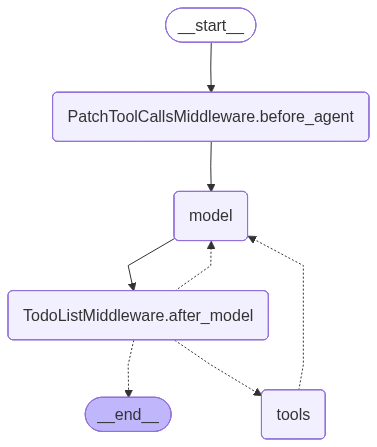

In [21]:
itinerary_research_agent

# PatchToolCallsMiddleware - Fix malformed tool calls from previous turns
# model - LLM call, direct answer or tool call
# TodoListMiddleware.after_model - runs after the model responds, Track tasks / plans the agent creates
# tools - actual tool execution (internet_search)

In [22]:
# Test Itinerary Agent
result = itinerary_research_agent.invoke({
    "messages": [
        {"role": "user",
         "content": "Plan a 5 day travel iternerary for a food & hstorical sites lover during winter in Delhi"
         }
        ]
    }
)

print(result)

{'messages': [HumanMessage(content='Plan a 5 day travel iternerary for a food & hstorical sites lover during winter in Delhi', additional_kwargs={}, response_metadata={}, id='e54b33be-aef7-4054-a2eb-c706b8831e35'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 6880, 'total_tokens': 6924, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DTgJ1kErXPMOcM6Gn1YnkbVjClH2U', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d7fda-4bfc-7a50-8460-adb933109070-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Delhi winter food walk Chandni Chowk Paranthe Wali Gali hours', 'search_depth': 'advance

In [23]:
result

{'messages': [HumanMessage(content='Plan a 5 day travel iternerary for a food & hstorical sites lover during winter in Delhi', additional_kwargs={}, response_metadata={}, id='e54b33be-aef7-4054-a2eb-c706b8831e35'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 44, 'prompt_tokens': 6880, 'total_tokens': 6924, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DTgJ1kErXPMOcM6Gn1YnkbVjClH2U', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d7fda-4bfc-7a50-8460-adb933109070-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'Delhi winter food walk Chandni Chowk Paranthe Wali Gali hours', 'search_depth': 'advan

In [24]:
# Human, System, AIMessage

In [25]:
# Print the agent's response
print(result["messages"][-1].content)

## 5-Day Winter Delhi Itinerary (Food + Historical Sites)
Best season for this plan: **Nov–Feb** (cool days, cold nights; ideal for walking + winter-only foods like *daulat ki chaat*).

**Getting around (recommended):**
- **Metro + short autos** for most sightseeing; **Uber/Ola** for flexibility.
- Consider a **Delhi Metro Tourist Card** (per DMRC PDF): **1-day ₹150** (₹100 value + ₹50 refundable deposit) or **3-day ₹300** (₹250 value + ₹50 refundable deposit). (Airport Express typically excluded.)

**Daily cost ballpark (per person, mid-range, excluding hotel):**
- Food + snacks: **₹800–₹2,500/day**
- Transport: **₹200–₹900/day** (more if using cabs all day)
- Monument tickets (Indians): typically **₹35–₹50** each for ASI sites; (Foreigners often **₹550–₹600** range at major ASI sites)

---

# Day 1 — Old Delhi Mughal Core + Winter Street Food (Chandni Chowk)
**Morning (9:00–12:30) | Red Fort + Chandni Chowk**
- **9:00–11:00**: **Red Fort (Lal Qila)**, Netaji Subhash Marg (Old Delhi) 

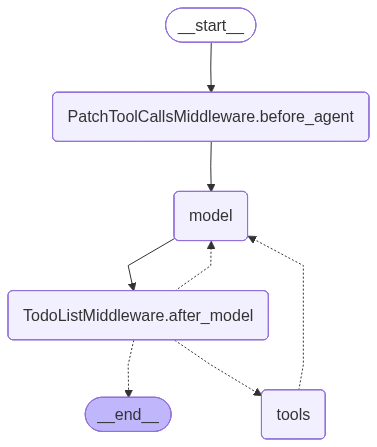

In [26]:
from IPython.display import Image, display

display(Image(itinerary_research_agent.get_graph().draw_mermaid_png()))

## Flight & Hotel Search Agent

### Flight & Hotel Search Tool

In [27]:
# API Key SetUp (Using Serp API for Flight & Hotel Serach)

try:
    api_key_from_secrets = userdata.get("SERPAPI_API_KEY")
    os.environ["SERPAPI_API_KEY"] = api_key_from_secrets
except Exception:
        os.environ["SERPAPI_API_KEY"] = getpass.getpass("Enter your Serp API key: ")

In [28]:
# Install required libraries

!pip install -q google-search-results

  Preparing metadata (setup.py) ... done


In [29]:
!pip install -q langchain-community

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 51.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.


In [30]:
from langchain_community.utilities import SerpAPIWrapper
from serpapi import GoogleSearch

In [31]:
import os
import json
from typing import Optional
from pydantic import BaseModel, Field
from serpapi import GoogleSearch
from langchain_core.tools import tool

In [32]:
## PyDantic Class

# LLM need a machine-readable schema for tool calling
# inputs are defined with Pydantic models or JSON schemas
# Pydantic - library for data validation, parsing, and serialization
# One of the primary ways of defining schema in Pydantic is via models.
# BaseModel is the core class in Pydantic.

from pydantic import BaseModel

class User(BaseModel):
    name: str
    age: int

data = {
    "name": "name",
    "age": "30"
}

user = User(**data)

# User becomes a validated data structure
user.age, type(user.age)

# Pydantic automatically converts types

(30, int)

In [33]:
User(name="name", age="abc")

ValidationError: 1 validation error for User
age
  Input should be a valid integer, unable to parse string as an integer [type=int_parsing, input_value='abc', input_type=str]
    For further information visit https://errors.pydantic.dev/2.12/v/int_parsing

In [34]:
# FLIGHT SEARCH TOOL
class FlightSearchInput(BaseModel):
    """Input schema for flight search."""

    departure_airport: str = Field(..., description="Departure airport code (e.g., 'JFK')")
    arrival_airport: str = Field(..., description="Arrival airport code (e.g., 'LAX')")
    outbound_date: str = Field(..., description="Departure date (YYYY-MM-DD)")
    return_date: Optional[str] = Field(None, description="Return date (YYYY-MM-DD)")
    adults: int = Field(1, description="Number of adults")
    children: int = Field(0, description="Number of children")
    stops: Optional[int] = Field(None, description="0=Any, 1=Nonstop, 2=1 stop or fewer")

@tool(args_schema=FlightSearchInput)
def search_flights(
    departure_airport: str,
    arrival_airport: str,
    outbound_date: str,
    return_date: Optional[str] = None,
    adults: int = 1,
    children: int = 0,
    stops: Optional[int] = None
) -> str:
    """Search for flights between airports."""

    params = {
        'api_key': os.environ.get('SERPAPI_API_KEY'),
        'engine': 'google_flights',
        'departure_id': departure_airport.upper(),
        'arrival_id': arrival_airport.upper(),
        'outbound_date': outbound_date,
        'adults': adults,
        'children': children,
        'currency': 'USD',
        'type': 1 if return_date else 2
    }

    if return_date:
        params['return_date'] = return_date
    if stops is not None:
        params['stops'] = stops

    try:
        results = GoogleSearch(params).get_dict()
        flights = results.get('best_flights', []) + results.get('other_flights', [])

        if not flights:
            return json.dumps({"message": "No flights found"})

        output = []
        for f in flights[:10]:
            output.append({
                "price": f.get("price"),
                "duration_mins": f.get("total_duration"),
                "airline_logo": f.get("airline_logo"),
                "legs": [{
                    "airline": leg.get("airline"),
                    "flight_number": leg.get("flight_number"),
                    "departure": f"{leg.get('departure_airport', {}).get('id')} {leg.get('departure_airport', {}).get('time')}",
                    "arrival": f"{leg.get('arrival_airport', {}).get('id')} {leg.get('arrival_airport', {}).get('time')}",
                    "airline_logo": leg.get("airline_logo")
                } for leg in f.get("flights", [])]
            })

        return json.dumps(output, indent=2)

    except Exception as e:
        return json.dumps({"error": str(e)})

In [35]:
# HOTEL SEARCH TOOL
class HotelSearchInput(BaseModel):
    """Input schema for hotel search."""

    location: str = Field(..., description="Location (e.g., 'New York', 'Paris')")
    check_in_date: str = Field(..., description="Check-in date (YYYY-MM-DD)")
    check_out_date: str = Field(..., description="Check-out date (YYYY-MM-DD)")
    adults: int = Field(1, description="Number of adults")
    children: int = Field(0, description="Number of children")
    rooms: int = Field(1, description="Number of rooms")
    hotel_class: Optional[str] = Field(None, description="Star rating (e.g., '3,4,5')")
    sort_by: int = Field(8, description="3=Price, 8=Rating, 13=Reviews")


@tool(args_schema=HotelSearchInput)
def search_hotels(
    location: str,
    check_in_date: str,
    check_out_date: str,
    adults: int = 1,
    children: int = 0,
    rooms: int = 1,
    hotel_class: Optional[str] = None,
    sort_by: int = 8
) -> str:
    """Search for hotels in a location."""

    params = {
        'api_key': os.environ.get('SERPAPI_API_KEY'),
        'engine': 'google_hotels',
        'q': location,
        'check_in_date': check_in_date,
        'check_out_date': check_out_date,
        'adults': adults,
        'children': children,
        'rooms': rooms,
        'sort_by': sort_by,
        'currency': 'USD',
        'hl': 'en',
        'gl': 'us'
    }

    if hotel_class:
        params['hotel_class'] = hotel_class

    try:
        results = GoogleSearch(params).get_dict()
        properties = results.get('properties', [])

        if not properties:
            return json.dumps({"message": "No hotels found"})

        output = []
        for h in properties[:5]:
            output.append({
                "name": h.get("name"),
                "price": h.get("rate_per_night", {}).get("lowest"),
                "rating": h.get("overall_rating"),
                "reviews": h.get("reviews"),
                "stars": h.get("hotel_class"),
                "thumbnail": h.get("images", [{}])[0].get("thumbnail") if h.get("images") else None
            })

        return json.dumps(output, indent=2)

    except Exception as e:
        return json.dumps({"error": str(e)})

In [36]:
search_tools = [search_flights, search_hotels]

### Flight & Hotel Search Prompt

In [37]:
# flightHotelSearch Agent Prompt

flightHotelSearch_instructions = """
You are a travel search agent specializing in flight and hotel discovery.
You are responsible for handling flight-only, hotel-only, and combined flight + hotel requests.

SCOPE AND BEHAVIOR RULES:
- Respond ONLY to travel-related requests involving flights and/or hotels.
- Politely decline and redirect if the request is unrelated to travel.
- You MUST use the appropriate tool(s) to retrieve current data.
- Do NOT fabricate availability, schedules, ratings, or prices.

AVAILABLE TOOLS:
You have exactly two tools:
- search_flights: Use to search for flights with structured flight inputs.
- search_hotels: Use to search for hotels with structured hotel inputs.

TOOL SELECTION RULES:
- Flight-only request → use search_flights
- Hotel-only request → use search_hotels
- Combined request → use BOTH tools
- Never call a tool if required inputs are missing.

REQUIRED INPUTS (ASK IF MISSING):

For search_flights:
- origin (city or airport code)
- destination (city or airport code) - this is optional
- departure_date (YYYY-MM-DD)
- return_date (YYYY-MM-DD) for round trips (if applicable)
- passengers

For search_hotels:
- destination/location (city or neighborhood)
- check_in (YYYY-MM-DD)
- check_out (YYYY-MM-DD)
- guests
- rooms
- preferences (star rating, amenities, rating threshold)
- budget_per_night or total_budget (if specified)

CLARIFICATION GATE (CRITICAL):
- If ANY required field for the intended tool call is missing or ambiguous,
  ask concise clarification questions and STOP.
- Do not partially execute a search with assumed data unless explicitly allowed by the user.

PROCESS (MANDATORY):
1. Classify the request as flight-only, hotel-only, or combined.
2. Extract all constraints and preferences from the user message.
3. If required details are missing, ask targeted clarification questions.
4. Call the appropriate tool(s) with well-formed structured input.
5. Analyze the returned results for relevance, trade-offs, and value.
6. Present clear, actionable recommendations.

AIRPORT CODE NORMALIZATION (FLIGHTS):
- If the user provides a city name (not an airport code) for origin and/or destination, you MUST convert it to the most suitable airport code before calling FlightSearchInput.
- Prefer the primary international airport for that city (or the best-served airport for typical commercial routes).
- If the city has multiple major airports (e.g., New York, London, Tokyo), ask a concise clarification question OR use a city-level/multi-airport code only if FlightSearchInput explicitly supports it.
- If you cannot confidently determine the correct airport code from the city name, ask a clarification question and STOP (do not guess).

OUTPUT REQUIREMENTS:

For Flight Results:
- Organize by outbound and return (if applicable)
- Include airline, timing, duration, layovers, cabin class, and price
- Highlight best options (e.g., fastest, cheapest, best value)

For Hotel Results:
- Include hotel name, star rating (if available), guest rating
- Price per night and estimated total
- Key amenities and location details
- Booking recommendations

For Combined Requests:
- Provide bundled recommendations (e.g., Value / Balanced / Comfort)
- Show estimated total trip cost (flight + hotel)
- Explain trade-offs clearly

FORMATTING GUIDELINES:
- Use clear headings and bullet points
- Optimize for quick comparison and decision-making
- Be concise, factual, and analytical

Airport code reference (examples):
- Delhi: DEL
- London Heathrow: LHR
- New York: JFK / LGA / EWR
- etc.
"""

### Test Flight & Hotel Search

In [38]:
# Test flightHotelSearch Agent
from langchain.agents import create_agent

search_agent = create_agent(
    model=llm,  # Default model
    tools=search_tools,
    system_prompt=flightHotelSearch_instructions
    # middleware=[dynamic_model_selection]
)

In [39]:
search_result = search_agent.invoke({
    "messages": [{
        "role": "user",
        "content": "Find me flight, returning on April 22, 2026 from New York to London on April 18, 2026 for 1 adults only"
        }]
    })

# Print the agent's response
print(search_result)
print(search_result["messages"][-1].content)

{'messages': [HumanMessage(content='Find me flight, returning on April 22, 2026 from New York to London on April 18, 2026 for 1 adults only', additional_kwargs={}, response_metadata={}, id='9f987ec4-3508-41d6-b408-d5b1b0b1fe57'), AIMessage(content='To search flights I just need one clarification about airports, since both cities have multiple major options:\n\n1) **New York departure airport**: **JFK, EWR, or LGA** (or “any NYC airport”)?\n2) **London arrival airport**: **LHR, LGW, STN, LTN, or LCY** (or “any London airport”)?\n3) Any preference for **nonstop only** vs **OK with 1 stop**?\n\nOnce you confirm, I’ll pull live options for **Apr 18, 2026 → Apr 22, 2026**, **1 adult**.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 134, 'prompt_tokens': 1203, 'total_tokens': 1337, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {

In [40]:
search_result = search_agent.invoke({
    "messages": [{
        "role": "user",
        "content": "Find me hotels on April 22, 2026 in London for 1 adults only for 2 nights"
        }]
    })

# Print the agent's response
print(search_result)
print(search_result["messages"][-1].content)

{'messages': [HumanMessage(content='Find me hotels on April 22, 2026 in London for 1 adults only for 2 nights', additional_kwargs={}, response_metadata={}, id='04626535-59a7-4558-80ff-b3f447a1002e'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 1194, 'total_tokens': 1257, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DTgPY45HKevlAwtJ6YKZwWm6Kej43', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d7fe0-7d8b-7780-add4-3b00bd95fd09-0', tool_calls=[{'name': 'search_hotels', 'args': {'location': 'London', 'check_in_date': '2026-04-22', 'check_out_date': '2026-04-24', 'adults': 1, 'children': 0, 

In [41]:
# Continuous Chat

messages = []

while True:
    user_input = input("User: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    messages.append({"role": "user", "content": user_input})
    result = search_agent.invoke({"messages": messages})
    assistant_message = result["messages"][-1]
    print("Assistant:", assistant_message.content)
    messages.append(assistant_message)

User: The Milestone Hotel and Residences
Assistant: To look up **The Milestone Hotel and Residences** and show current availability/prices, I need the stay details:

1) **City**: London (Kensington) — is that the one you mean?  
2) **Check-in date** (YYYY-MM-DD)  
3) **Check-out date** (YYYY-MM-DD)  
4) **Guests** (adults/children)  
5) **Rooms** (e.g., 1)

Reply with those and I’ll run a live hotel search for it and close alternatives nearby if it’s sold out.
User: 1.London 2. April 20, 2026 3. April 22, 2026 4. 2 adults, 1 child 5. 1
Assistant: I searched **London** for **2026-04-20 → 2026-04-22** (1 room, **2 adults + 1 child**) and the live hotel feed returned **“No hotels found”** for that query, so I’m not able to show availability/pricing for **The Milestone Hotel and Residences** right now.

To retry successfully, please confirm one of the following (any one is enough):

1) **Exact hotel match**: Is the property **“The Milestone Hotel & Residences, Kensington (near Hyde Park)”*

In [42]:
# Continuous Chat

messages = []

while True:
    user_input = input("User: ")
    if user_input.lower() in ["exit", "quit"]:
        break
    messages.append({"role": "user", "content": user_input})
    result = search_agent.invoke({"messages": messages})
    assistant_message = result["messages"][-1]
    print("Assistant:", assistant_message.content)
    messages.append(assistant_message)

User: exit


In [43]:
for event in search_agent.stream(
    {"messages": [{
        "role": "user",
        "content": "Find me hotels Check-in April 22 2026, check-out April 24 2026 in London 1 room only"
        }]
     },
    stream_mode="values",):
      # print(event)
      event["messages"][-1].pretty_print()

================================ Human Message =================================

Find me hotels Check-in April 22 2026, check-out April 24 2026 in London 1 room only
================================== Ai Message ==================================
Tool Calls:
  search_hotels (call_rJA9TEdIVFjdnXSetbYisy49)
 Call ID: call_rJA9TEdIVFjdnXSetbYisy49
  Args:
    location: London
    check_in_date: 2026-04-22
    check_out_date: 2026-04-24
    rooms: 1
    sort_by: 8
================================= Tool Message =================================
Name: search_hotels

[
  {
    "name": "Wilde Aparthotels, London, Covent Garden",
    "price": "$327",
    "rating": 4.9,
    "reviews": 4622,
    "stars": "4-star hotel",
    "thumbnail": "https://lh3.googleusercontent.com/gps-cs-s/APNQkAFCbOp3zOMtBPXGO86ICkodd4HBljbVtlyDNSVxy9ga27DlvJFVBg1JJF3Z-xhkt61Qs4dGqjIpNXa3I_hwF15Pk3vdFVqQ-hEfBc_lUk2ICQGZoz-cyKeGmbWFTLQPNa987Mb_-g=s287-w287-h192-n-k-no-v1"
  },
  {
    "name": "Wilde Aparthotels, London, P

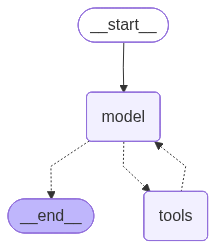

In [44]:
from IPython.display import Image, display

display(Image(search_agent.get_graph().draw_mermaid_png()))

## Travel Scout (for General Queries)

### Travel Scout Prompt

In [45]:
# Travel Scout Prompt

travel_scout_instructions = """
You are a General Travel Scout specializing in high-level travel information and guidance.
Your role is to answer general travel questions that do NOT require detailed itinerary planning,
flight searches, or hotel booking.

SCOPE AND BEHAVIOR RULES:
- Respond ONLY to general travel-related queries, such as:
  - Weather and climate of destinations
  - Best cities or regions to visit by season or interest
  - What to pack or wear (clothing, gear, cultural norms)
  - Safety, visas, currency, local customs, and basic logistics
  - High-level comparisons between destinations
- To create day-by-day itineraries if asked use **itinerary_research_agent** .
- Do NOT search or recommend specific flights or hotels.
- Politely decline and redirect if the request is unrelated to travel.

--------------------------------------------------
TOOL SELECTION RULES (CRITICAL)
--------------------------------------------------

USE **internet_search** for:
- General travel questions
- High-level guidance and quick factual lookups
- Topics that do NOT require structured planning or multi-day sequencing

Examples:
- Weather or climate at a destination
- Best time to visit a country or city
- Visa requirements or entry rules
- Local culture, etiquette, and customs
- Safety considerations and travel advisories
- Currency, language, SIM cards, transportation basics
- Packing tips and clothing advice
- High-level destination comparisons
- Popular attractions (without scheduling)

DO NOT create day-by-day itineraries when using internet_search.

--------------------------------------------------

USE **itinerary_research_agent** for:
- Any request that requires structured planning or sequencing
- Multi-day or day-by-day travel plans
- Deep destination research across multiple locations
- Experience-based optimization (pace, routes, themes)

Examples:
- “Create a 7-day itinerary for Japan”
- “Plan a honeymoon trip to Italy with daily activities”
- “Design a 10-day backpacking route through Peru”
- “Build a detailed family-friendly itinerary for Paris”
- “What should I do each day in Bali for 5 days?”

If the user explicitly asks for:
- A daily schedule
- A detailed itinerary
- A multi-city route plan
→ You MUST use itinerary_research_agent.

PROCESS (MANDATORY):
1. Identify the intent and depth of the travel question.
2. Select the correct tool based on Tool Selection Rules.
3. Execute the tool.
4. Synthesize results into a clear, concise, traveler-friendly response.
5. State assumptions, seasonal variations, or uncertainty if applicable.


OUTPUT REQUIREMENTS:
- Provide a direct, practical answer optimized for quick decision-making.
- Avoid deep research, long narratives, or detailed schedules.
- Include actionable tips when helpful (e.g., “best months,” “what to avoid,” “what to pack”).

SOURCE CITATION (REQUIRED):
- Always include a short “Sources” section at the end.
- Cite 2–4 reputable sources used via TavilySearch.
- Do not include raw URLs in the body; list sources clearly and concisely.

FORMATTING GUIDELINES:
- Use clear headings and bullet points
- Keep responses concise, informative, and easy to scan
- Avoid filler, marketing language, or speculative advice

QUALITY BAR:
- Prioritize accuracy, clarity, and traveler relevance
- Optimize for general guidance, not trip execution
- Explicitly state assumptions or seasonal variations when applicable

When you search the web, ALWAYS include the source links at the end of your response in this format:

**Sources:**
- [Title](URL)
- [Title](URL)

This helps users verify information and explore further.
"""


### itinerary_research_agent as a Tool (Sub Agent)

In [46]:
# Defining itinerary_research_agent as a Tool
# creates a wrapper function for invoking the agent: itinerary_research_agent

@tool("itinerary_research_subagent", description="plans travel itinerary")
def call_itinerary_research_agent(query: str):
    result = itinerary_research_agent.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content

### Test Travel Scout

In [47]:
travel_scout = create_agent(
    model=llm,
    system_prompt=travel_scout_instructions,
    tools=[internet_search, call_itinerary_research_agent]
)

In [48]:
travel_scout_result = travel_scout.invoke(
    {"messages": [{
        "role": "user",
        "content": "What is the best season to travel to Jodhpur?"
        }]
  })
print(travel_scout_result["messages"][-1].content)

## Best season to travel to Jodhpur

**Winter / cool season is best: October to March.**  
This is when Jodhpur has **comfortable daytime temperatures, low humidity, and cool evenings**, making sightseeing (Mehrangarh Fort, old “Blue City” lanes, markets) much more pleasant than in the hotter months.

### Quick seasonal notes
- **Best overall months:** **November–February** (coolest, most comfortable; also peak crowds/prices)
- **Good shoulder months:** **October & March** (still pleasant, often slightly fewer crowds; March starts warming up)
- **Least comfortable:** **April–June** (very hot, desert heat can be intense)
- **Monsoon:** **July–September** (greener and cooler than summer, but humidity and occasional heavy rain can disrupt plans)

### What to pack (Oct–Mar)
- Light layers for day + **a warm layer for evenings/mornings** (it can feel chilly at night in winter).

**Sources:**
- [SOTC – Best Time to Visit Jodhpur](https://www.sotc.in/tourism/jodhpur-tourism/best-time-to-visit

In [49]:
travel_scout_result

{'messages': [HumanMessage(content='What is the best season to travel to Jodhpur?', additional_kwargs={}, response_metadata={}, id='d0711fe0-cce2-4f8d-9f63-01eb4ee8e012'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 2039, 'total_tokens': 2077, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DTgZnItOE6Ljf7RJ4ZbCDTW6ZYuMF', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d7fea-2d4e-7671-af2d-0efdedeb7de5-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'best time to visit Jodhpur season October March weather', 'search_depth': 'basic', 'topic': 'general'}, 'id': 'call_Sj3no3q004Nwu

In [50]:
travel_scout_result = travel_scout.invoke(
    {"messages": [{
        "role": "user",
        "content": "Plan 2 day itinerary for Agra travel for a history & culture lover, also want to try special cusine to this city"
        }]
     }
)
print(travel_scout_result["messages"][-1].content)

## 2-day Agra itinerary (History + Culture + Local cuisine)
Assumes you’re staying in Agra city and using Uber/Ola or auto-rickshaws for local travel. **Key note: Taj Mahal is closed on Fridays**, so swap Day 1/Day 2 morning slots if needed.

---

## Day 1 — Taj Mahal masterpieces + riverside sunset + Agra snacks
### Early morning: **Taj Mahal (sunrise visit)**
- Go **at/just before sunrise** for the best light and fewer crowds.
- Allocate **2.5–3 hours** including entry/security lines.
- Tip: the **East Gate** often feels smoother for many visitors (depends on your location and crowd flow).

### Late morning: **Agra breakfast (local classic)**
Try:
- **Bedai (or Bedhai)** + **aloo sabzi**
- **Jalebi** (hot, fresh)
- Chai or lassi  
This is a very “Agra morning” food experience.

### Midday: **Itimad-ud-Daulah (Baby Taj)**
- A must for architecture lovers: delicate marble, inlay work, and a quieter, more intimate monument than the big ones.
- Great for photography and understanding Mug

In [53]:
travel_scout_result["messages"]

[HumanMessage(content='Plan 2 day itinerary for Agra travel for a history & culture lover, also want to try special cusine to this city', additional_kwargs={}, response_metadata={}, id='4337dcaa-c0a1-463a-aac0-a6f545dbfaed'),
 AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 2053, 'total_tokens': 2111, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DTgaFYKYWlMMWI6OKSU4x7E5x3h5c', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d7fea-9b7b-7d42-a5ac-84c0d4e15746-0', tool_calls=[{'name': 'itinerary_research_subagent', 'args': {'query': 'Create a 2-day itinerary for Agra for a history and culture lo

### Streaming

In [54]:
# Stream events
query = "What is the best season to travel to Jodhpur?"
for chunk in travel_scout.stream(
    {"messages": [{"role": "user", "content": query}]}
):
    print(chunk)


{'model': {'messages': [AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 2039, 'total_tokens': 2073, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1536}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DTgbkUrGACVQbMwsLh0zQARRpdqCd', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d7fec-096d-7221-b6b6-8f6355710d8d-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'best time to visit Jodhpur season October March weather', 'search_depth': 'basic'}, 'id': 'call_uZsj3UyjLnuaLLXjiNOrt0zT', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 2039, 'output_tokens': 34, 'total_tokens': 2073, 'input_token_details': {'a

In [55]:
for event in travel_scout.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",):
      # print(event)
      event["messages"][-1].pretty_print()

================================ Human Message =================================

What is the best season to travel to Jodhpur?
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_PDBilr3Al6HCksy3X8yDyhft)
 Call ID: call_PDBilr3Al6HCksy3X8yDyhft
  Args:
    query: best time to visit Jodhpur season October March weather
    search_depth: basic
    topic: general
================================= Tool Message =================================
Name: tavily_search

{"query": "best time to visit Jodhpur season October March weather", "response_time": 4.51, "follow_up_questions": null, "answer": null, "images": [{"url": "https://images.climate-data.org/location/2848/10/climate-graph-800.png", "title": "Weather Jodhpur in October 2026: Temperature & Climate", "description": "A temperature and rainfall chart showing a gradual decrease in temperature from October to March with a slight fluctuation in rainfall during these months in 

In [56]:
query = "Plan 2 day itinerary for Agra travel for a history & culture lover, also want to try special cusine to this city"
for event in travel_scout.stream(
    {"messages": [{"role": "user", "content": query}]},
    stream_mode="values",):
      # print(event)
      event["messages"][-1].pretty_print()

================================ Human Message =================================

Plan 2 day itinerary for Agra travel for a history & culture lover, also want to try special cusine to this city
================================== Ai Message ==================================
Tool Calls:
  itinerary_research_subagent (call_XxBeiuAkFar8vYBrk63yBovl)
 Call ID: call_XxBeiuAkFar8vYBrk63yBovl
  Args:
    query: Create a 2-day Agra itinerary for a history & culture lover including key Mughal sites (Taj Mahal, Agra Fort, Itimad-ud-Daulah, Mehtab Bagh, Fatehpur Sikri optional), local bazaars, museums, and recommendations for Agra-specific cuisine/food experiences. Include practical tips on timing (sunrise Taj), tickets, guides, local transport, best areas for food, and cultural etiquette. Avoid specific hotel/flight bookings.
================================= Tool Message =================================
Name: itinerary_research_subagent

## 2-day Agra itinerary (history & culture focus; Mugha

In [ ]:
# search_agent (agent 1)
# travel_scout (agent 2)
# they are independent single agents

# By not using the agents directly
# but by using raw LLMs

# **Step 4 - Design Your Agent State**




## Graph State

In [57]:
from typing import TypedDict, Annotated, List, Optional
import operator
from langchain.messages import AnyMessage

In [58]:
class AgentTask(BaseModel):
    """A single agent task with targeted query."""
    source: Literal["search_agent_node", "planner_agent_node"]
    user_query: str
    focus: str = ""  # What aspect this agent should focus on

In [59]:
##### Main Graph State ######

# TypedDict - defines a structural type for dictionaries with a fixed set of string keys and specific value types,
# enabling static type checking for JSON-like structures
# no runtime validation like Pydantic (used in tools)

class TravelPlannerState(TypedDict):
    """Enhanced state for parallel execution."""

    # Conversation history
    messages: Annotated[List[AnyMessage], operator.add]

    # Current user query
    user_query: str

    # Tasks from router (replaces single classification)
    tasks: List[AgentTask]

    # Flag for synthesis
    requires_synthesis: bool

    # Parallel agent results - KEY: uses operator.add for concurrent writes
    agent_results: Annotated[List[dict], operator.add]

    # Final synthesized answer
    final_answer: str

    search_messages: Annotated[List[AnyMessage], operator.add]
    planner_messages: Annotated[List[AnyMessage], operator.add]

# **Step 5 - Build Your Nodes**

## Orchestrator


*  Breaks down tasks into subtasks
*  Delegates subtasks to workers/nodes


*   Synthesizes worker outputs into a final result

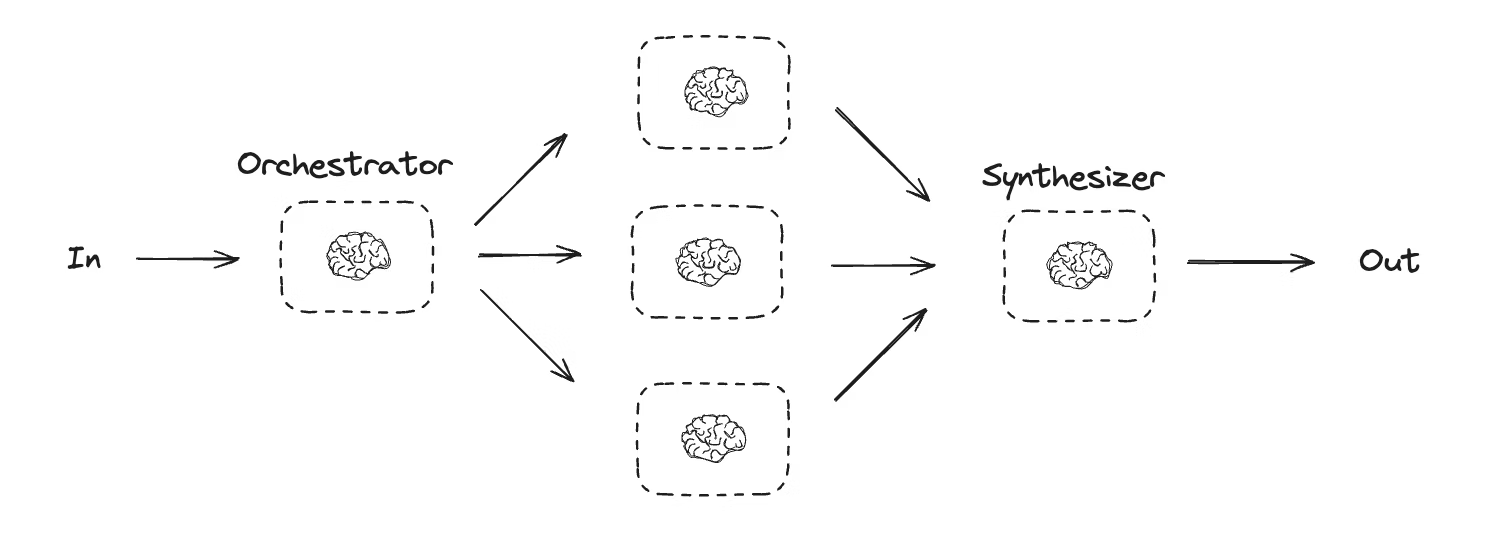






In [60]:
from langgraph.types import Send
from langchain.messages import SystemMessage, ToolMessage, HumanMessage, AIMessage

In [61]:
class ClassificationResult(BaseModel):
    """Router output - now supports MULTIPLE parallel tasks."""
    tasks: List[AgentTask] = Field(
        description="List of agents to invoke with their targeted queries"
    )
    requires_synthesis: bool = Field(
        default=False,
        description="Whether multiple agents are being used and synthesis is needed"
    )

In [62]:
# # Worker/Node state for individual agents
# class AgentWorkerState(TypedDict):
#     """State passed to each parallel worker."""
#     task: AgentTask
#     messages: List[AnyMessage]
#     agent_results: Annotated[List[dict], operator.add]

In [63]:
# Structured Output
# Models can be requested to provide their response in a format matching a given schema.
# This is useful for ensuring the output can be easily parsed and used in subsequent processing

from pydantic import BaseModel, Field

class Movie(BaseModel):
    """A movie with details."""
    title: str = Field(..., description="The title of the movie")
    year: int = Field(..., description="The year the movie was released")
    director: str = Field(..., description="The director of the movie")
    rating: float = Field(..., description="The movie's rating out of 10")

model = ChatOpenAI(temperature=0.2)
model_with_structure = model.with_structured_output(Movie)
response = model_with_structure.invoke("Provide details about the movie Inception")
response

# Movie(title="Inception", year=2010, director="Christopher Nolan", rating=8.8)

/usr/local/lib/python3.12/dist-packages/langchain_openai/chat_models/base.py:2210: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


Movie(title='Inception', year=2010, director='Christopher Nolan', rating=8.8)

In [64]:
def classify_query_parallel(state: TravelPlannerState) -> dict:
    """
    Updated router that can dispatch to MULTIPLE agents.
    """
    router_llm = llm
    structured_llm = router_llm.with_structured_output(ClassificationResult)

    result = structured_llm.invoke([
        {
            "role": "system",
            "content": """
            You are a Travel Request Router that can dispatch to MULTIPLE agents in parallel.

            AVAILABLE AGENTS:
            1. search_agent_node - Flight searches, hotel searches, pricing, availability
            2. planner_agent_node - Itineraries, travel tips, weather, visas, activities, general guidance

            ROUTING RULES:

            SINGLE AGENT (requires_synthesis = false):
            - Flight/hotel ONLY → search_agent_node
            - Itinerary/planning ONLY → planner_agent_node
            - General travel questions → planner_agent_node

            MULTIPLE AGENTS (requires_synthesis = true):
            - "Plan a trip AND find flights/hotels" → BOTH agents
            - "Find hotels and create itinerary" → BOTH agents
            - Requests mentioning BOTH booking AND planning → BOTH agents

            When dispatching to BOTH agents:
            1. Create a focused sub-query for each agent
            2. search_agent_node query should focus on flights/hotels/pricing
            3. planner_agent_node query should focus on itinerary/activities/tips

            EXAMPLES:

            Query: "Find flights from DEL to DXB"
            → tasks: [{"source": "search_agent_node", "user_query": "Find flights from DEL to DXB"}]
            → requires_synthesis: false

            Query: "Plan a 5-day trip to Paris"
            → tasks: [{"source": "planner_agent_node", "user_query": "Plan a 5-day trip to Paris"}]
            → requires_synthesis: false

            Query: "Plan a week in London and find me hotels under $200/night"
            → tasks: [
                {"source": "search_agent_node", "user_query": "Find hotels in London under $200/night for 1 week", "focus": "hotel search and pricing"},
                {"source": "planner_agent_node", "user_query": "Plan a week-long itinerary for London", "focus": "daily activities and attractions"}
              ]
            → requires_synthesis: true

            Query: "I want to visit Tokyo - book flights from NYC and create a 5-day itinerary"
            → tasks: [
                {"source": "search_agent_node", "user_query": "Find flights from NYC to Tokyo", "focus": "flight options and prices"},
                {"source": "planner_agent_node", "user_query": "Create a 5-day itinerary for Tokyo", "focus": "daily schedule and activities"}
              ]
            → requires_synthesis: true
            """
        },
        {"role": "user", "content": state["user_query"]}
    ])

    return {
        "tasks": result.tasks,
        "requires_synthesis": result.requires_synthesis
    }


In [65]:
def dispatch_to_agents(state: TravelPlannerState):
    """
    Uses Send API to dispatch tasks to agents in PARALLEL.
    This is the key function that enables concurrent execution.
    """
    tasks = state.get("tasks", [])

    sends = []
    for task in tasks:

        worker_state = {
              "messages": state.get("messages", []),
              "user_query": task.user_query,
              "tasks": state.get("tasks", []),
              "requires_synthesis": state.get("requires_synthesis", False),
              "agent_results": [],  # Each worker starts fresh
              "final_answer": "",
              "search_messages": [],  # Initialize empty for workers
              "planner_messages": [],  # Initialize empty for workers
        }

        if task.source == "search_agent_node":
            sends.append(Send("search_agent_node", worker_state))  # Your existing node
        elif task.source == "planner_agent_node":
            sends.append(Send("planner_agent_node", worker_state))  # Your existing node

    return sends

### Synthesizer

In [66]:
def synthesizer_node(state: TravelPlannerState) -> dict:
    """
    Combines results from parallel agents into a unified response.
    Only called when requires_synthesis is True.
    """

    agent_results = state.get("agent_results", [])

    if not agent_results:
        return {
            "final_answer": "I couldn't process your request.",
            "messages": [AIMessage(content="I couldn't process your request.")]
        }

    # If only one result, no synthesis needed
    if len(agent_results) == 1:
        result = agent_results[0]["result"]
        return {
            "final_answer": result,
            "messages": [AIMessage(content=result)]
        }

    # Format results for synthesis
    results_formatted = "\n\n" + "="*50 + "\n\n".join([
        f"**{r['agent'].upper()}**\nFocus: {r.get('focus', 'N/A')}\n\n{r['result']}"
        for r in agent_results
    ])

    #     ==================================================
    # **SEARCH_AGENT**
    # Focus: hotels
    # Top hotels in Madrid...

    # **PLANNER_AGENT**
    # Focus: 3 day itinerary
    # Day 1: Prado museum...

    synthesis_prompt = """
    You are a Travel Response Synthesizer. Combine multiple agent outputs into a single, well-organized, comprehensive response.

    RULES:
    1. Organize logically (e.g., Flights → Hotels → Itinerary → Tips)
    2. Don't repeat information
    3. Highlight key recommendations
    4. Note any conflicts or alternatives
    5. Create clear sections with headers
    6. End with actionable next steps

    Original Query: {query}

    Agent Results:
    {results}

    Create a unified, helpful response:
    """

    response = llm.invoke([
        HumanMessage(content=synthesis_prompt.format(
            query=state["user_query"],
            results=results_formatted
        ))
    ])

    return {
        "final_answer": response.content,
        "messages": [AIMessage(content=response.content)]
    }

## Define Search (Flight & Hotel) and PLanner (TravelScout & ItineraryResearch) Nodes

### Augment the LLM with tools

In [67]:
# Tool Calling vs Tool Execution

# When binding user-defined tools, the model’s response includes a request to execute a tool.
# When using a model separately from an agent, it is up to you to execute the requested tool and
# return the result back to the model for use in subsequent reasoning.

# When using an agent, the agent loop will handle the tool execution loop for you.

In [68]:
search_tools

[StructuredTool(name='search_flights', description='Search for flights between airports.', args_schema=<class '__main__.FlightSearchInput'>, func=<function search_flights at 0x7abf39b51080>),
 StructuredTool(name='search_hotels', description='Search for hotels in a location.', args_schema=<class '__main__.HotelSearchInput'>, func=<function search_hotels at 0x7abf39b509a0>)]

In [69]:
# Augment the LLM with tools
search_tools_by_name = {tool.name: tool for tool in search_tools} #
search_model_with_tools = llm.bind_tools(search_tools)

In [70]:
planner_tools = [internet_search, call_itinerary_research_agent]
planner_model_with_tools = llm.bind_tools(planner_tools)

### Search Agent & Tool Node

In [71]:
def search_agent_node(state: TravelPlannerState):
    """Search agent with its own message history"""

    # Use search-specific messages
    search_msgs = state.get("search_messages", [])

    messages = [SystemMessage(content=flightHotelSearch_instructions)] + search_msgs

    # If this is first call, add the user query
    if not search_msgs:
        messages.append(HumanMessage(content=state.get("user_query", "")))

    response = search_model_with_tools.invoke(messages)

    return {
        "search_messages": [response],
        "agent_results": [{
            "agent": "search_agent",
            "focus": "flights and hotels",
            "result": response.content
        }] if not response.tool_calls else []
    }

In [72]:
def search_tool_node(state: TravelPlannerState):
    """Execute search tools"""
    search_msgs = state.get("search_messages", [])

    # Check if search_messages exists and has content
    if not search_msgs:
        return {"search_messages": []}

    last_message = search_msgs[-1]

    # Check if last_message has tool_calls
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return {"search_messages": []}

    result = []
    for tool_call in last_message.tool_calls:
        tool = search_tools_by_name.get(tool_call["name"])
        if tool:
            observation = tool.invoke(tool_call["args"])
            result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    return {"search_messages": result}

In [73]:
search_model_with_tools.invoke("Find me hotels Check-in April 22 2026, check-out April 24 2026 in London 1 room only")

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 438, 'total_tokens': 496, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.2-2025-12-11', 'system_fingerprint': None, 'id': 'chatcmpl-DTgeqyYI7ti5e6OpYEbPkdC1oDoky', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d7fee-f529-70b1-af3b-f885334a297b-0', tool_calls=[{'name': 'search_hotels', 'args': {'location': 'London', 'check_in_date': '2026-04-22', 'check_out_date': '2026-04-24', 'rooms': 1, 'adults': 1, 'children': 0, 'sort_by': 8}, 'id': 'call_0goYZXOe7FLYlKIAc6dPbhrM', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 438, 'output_tokens': 58, 'total_tokens': 496, 'input_toke

### Planner Agent & Tool Node

In [74]:
def planner_agent_node(state: TravelPlannerState):
    """Planner agent with its own message history"""

    # Use planner-specific messages
    planner_msgs = state.get("planner_messages", [])

    messages = [SystemMessage(content=travel_scout_instructions)] + planner_msgs

    # If this is first call, add the user query
    if not planner_msgs:
        messages.append(HumanMessage(content=state.get("user_query", "")))

    response = planner_model_with_tools.invoke(messages)

    return {
        "planner_messages": [response],
        "agent_results": [{
            "agent": "planner_agent",
            "focus": "travel planning and itinerary",
            "result": response.content
        }] if not response.tool_calls else []
    }

In [75]:
def planner_tool_node(state: TravelPlannerState):
    """Execute planner tools"""
    planner_msgs = state.get("planner_messages", [])

    # Check if planner_messages exists and has content
    if not planner_msgs:
        return {"planner_messages": []}

    last_message = planner_msgs[-1]

    # Check if last_message has tool_calls
    if not hasattr(last_message, 'tool_calls') or not last_message.tool_calls:
        return {"planner_messages": []}

    planner_tools_by_name = {tool.name: tool for tool in planner_tools}
    result = []

    for tool_call in last_message.tool_calls:
        tool = planner_tools_by_name.get(tool_call["name"])
        if tool:
            observation = tool.invoke(tool_call["args"])
            result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))

    return {"planner_messages": result}

### Conditional Edges

In [76]:
def should_continue_for_searchAgent(state: TravelPlannerState):
    search_msgs = state.get("search_messages", [])
    if search_msgs and hasattr(search_msgs[-1], 'tool_calls') and search_msgs[-1].tool_calls:
        return "search_tool_node"
    return "synthesizer"

In [77]:
def should_continue_for_plannerAgent(state: TravelPlannerState):
    """Check if planner needs to continue tool loop"""
    planner_msgs = state.get("planner_messages", [])
    if planner_msgs and hasattr(planner_msgs[-1], 'tool_calls') and planner_msgs[-1].tool_calls:
        return "planner_tool_node"
    return "synthesizer"

# **Step 6 - Build & Compile Your Workflow**

In [78]:
from typing import Literal
from langgraph.graph import StateGraph, START, END

In [79]:
def build_parallel_travel_agent():
    """Build the graph with parallel execution support."""

    builder = StateGraph(TravelPlannerState)

    # Add nodes
    builder.add_node("orchestrator", classify_query_parallel)
    builder.add_node("search_agent_node", search_agent_node)
    builder.add_node("planner_agent_node", planner_agent_node)
    builder.add_node("search_tool_node", search_tool_node)
    builder.add_node("planner_tool_node", planner_tool_node)
    builder.add_node("synthesizer", synthesizer_node)

    # Connect edges
    builder.add_edge(START, "orchestrator")

    # Router dispatches to agents via Send API (parallel execution)
    builder.add_conditional_edges(
        "orchestrator",
        dispatch_to_agents,
        ["search_agent_node", "planner_agent_node"] # dictionary {'k1':'node1', 'k2':'node2'}
    )

    # Search agent tool loop
    builder.add_conditional_edges(
        "search_agent_node",
        should_continue_for_searchAgent,
        ["search_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("search_tool_node", "search_agent_node")

    # Planner agent tool loop
    builder.add_conditional_edges(
        "planner_agent_node",
        should_continue_for_plannerAgent,
        ["planner_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("planner_tool_node", "planner_agent_node")

    # End after synthesis
    builder.add_edge("synthesizer", END)

    return builder.compile()

In [80]:
# Compile the agent
agent = build_parallel_travel_agent()

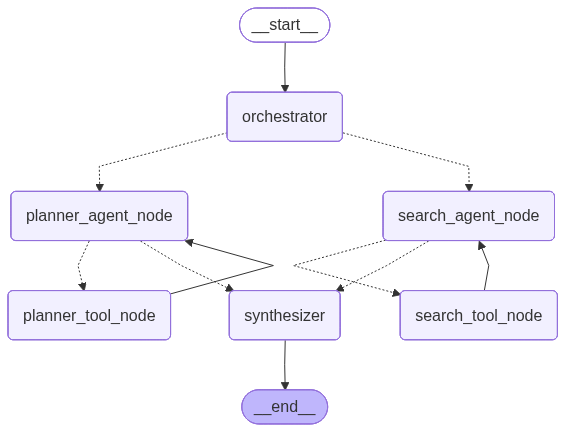

In [81]:
# Show the agent
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

# **Step 7 - Test the Multi-Agent System**






### Test Multi-Agent Travel Planner

In [82]:
result = agent.invoke({
        "user_query": """
                      Plan a 5-day trip to London and find me flights and hotels from JFK to LHR
                      for 1 adult only from 21 Apr 2026 to 26 Apr 2026 (one way trip)
                      """,
        "messages": []
    })

In [83]:
# Print everything step by step
print("=" * 60)
print("USER QUERY:")
print(result["user_query"])

print("\n" + "=" * 60)
print("TASKS DISPATCHED:")
for task in result.get("tasks", []):
    print(f"  • {task.source}: {task.user_query}")

print("\n" + "=" * 60)
print("AGENT RESULTS:")
for r in result.get("agent_results", []):
    print(f"\n[{r['agent'].upper()}]")
    print("-" * 40)
    print(r["result"][:50000] + "..." if len(r["result"]) > 500 else r["result"])

print("\n" + "=" * 60)
print("FINAL SYNTHESIZED RESPONSE:")
print("=" * 60)
print(result["final_answer"])

USER QUERY:

                      Plan a 5-day trip to London and find me flights and hotels from JFK to LHR
                      for 1 adult only from 21 Apr 2026 to 26 Apr 2026 (one way trip)
                      

TASKS DISPATCHED:
  • search_agent_node: Find one-way flights for 1 adult from JFK to LHR departing 21 Apr 2026, and hotels in London for 21 Apr 2026 to 26 Apr 2026 (5 nights). Provide options across budget/midrange with prices, locations, and key amenities.
  • planner_agent_node: Create a 5-day London itinerary for 1 adult visiting 21 Apr 2026 to 26 Apr 2026, with logical neighborhood grouping, transport tips, and a mix of top sights + local experiences.

AGENT RESULTS:

[SEARCH_AGENT]
----------------------------------------
## Flights (one-way) — JFK → LHR | Tue, 2026-04-21 | 1 adult
All options below are **nonstop** and currently showing **$395**:

**Best (fastest duration)**
- **British Airways BA 178** — 07:50 → 19:45 — **6h 55m** — Nonstop — $395
- **Virgin Atla

# **Add Persistence**

In [84]:
from langgraph.checkpoint.memory import InMemorySaver
from langchain_core.runnables import RunnableConfig

In [85]:
def build_parallel_travel_agent():
    """Build the graph with parallel execution support."""

    builder = StateGraph(TravelPlannerState)

    # Add nodes
    builder.add_node("orchestrator", classify_query_parallel)
    builder.add_node("search_agent_node", search_agent_node)
    builder.add_node("planner_agent_node", planner_agent_node)
    builder.add_node("search_tool_node", search_tool_node)
    builder.add_node("planner_tool_node", planner_tool_node)
    builder.add_node("synthesizer", synthesizer_node)

    # Connect edges
    builder.add_edge(START, "orchestrator")

    # Router dispatches to agents via Send API (parallel execution)
    builder.add_conditional_edges(
        "orchestrator",
        dispatch_to_agents,
        ["search_agent_node", "planner_agent_node"]
    )

    # Search agent tool loop
    builder.add_conditional_edges(
        "search_agent_node",
        should_continue_for_searchAgent,
        ["search_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("search_tool_node", "search_agent_node")

    # Planner agent tool loop
    builder.add_conditional_edges(
        "planner_agent_node",
        should_continue_for_plannerAgent,
        ["planner_tool_node", "synthesizer"]  # Go to synthesizer instead of END
    )
    builder.add_edge("planner_tool_node", "planner_agent_node")

    # End after synthesis
    builder.add_edge("synthesizer", END)

    # Built-in Persistence
    checkpointer = InMemorySaver()

    return builder.compile(checkpointer=checkpointer)

In [86]:
# Compile the agent
pers_agent = build_parallel_travel_agent()

In [87]:
config = {"configurable": {"thread_id": "user-01"}}

In [88]:
result = pers_agent.invoke(
    {
        "user_query": "What is the best time to visit Jaipur?",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config
)

print(result['final_answer'])

### Best time to visit Jaipur (weather-focused)
**October to March** is generally the best window for Jaipur because it’s **cooler, drier, and more comfortable for sightseeing** than the extreme summer and humid monsoon.

#### What each part of the season feels like
- **October–November (shoulder season):** Warm days, cooler evenings; usually dry and pleasant. Good balance of weather + fewer crowds than mid-winter.
- **December–January (peak winter):** Coolest months; **nights/mornings can feel quite chilly** (especially outdoors), while days are typically mild. Expect the **most crowds**.
- **February–March:** Warming up again; still great for sightseeing, with March starting to feel hotter by midday.

### Quick packing pointers for Oct–Mar
- **Layers:** light jacket/hoodie for evenings (especially Dec–Jan)
- **Daytime:** breathable clothes + sun protection (hat/sunscreen), as the sun can still be strong
- **Footwear:** comfortable walking shoes for forts/markets

**Sources:**
- [Best

In [89]:
len(list(pers_agent.get_state_history(config)))


7

In [90]:
snapshot = pers_agent.get_state(config)
snapshot

StateSnapshot(values={'messages': [AIMessage(content='### Best time to visit Jaipur (weather-focused)\n**October to March** is generally the best window for Jaipur because it’s **cooler, drier, and more comfortable for sightseeing** than the extreme summer and humid monsoon.\n\n#### What each part of the season feels like\n- **October–November (shoulder season):** Warm days, cooler evenings; usually dry and pleasant. Good balance of weather + fewer crowds than mid-winter.\n- **December–January (peak winter):** Coolest months; **nights/mornings can feel quite chilly** (especially outdoors), while days are typically mild. Expect the **most crowds**.\n- **February–March:** Warming up again; still great for sightseeing, with March starting to feel hotter by midday.\n\n### Quick packing pointers for Oct–Mar\n- **Layers:** light jacket/hoodie for evenings (especially Dec–Jan)\n- **Daytime:** breathable clothes + sun protection (hat/sunscreen), as the sun can still be strong\n- **Footwear:** 

In [91]:
# agent.get_state(config)
# len(list(agent.get_state_history(config)))

In [92]:
result = agent.invoke(
    {
        "user_query": "Major historical sites there (must visit kind of)",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config
)

print(result['final_answer'])

Which destination do you mean (city/region/country)?

To tailor the “must-visit” historical sites list, a few quick details:
1) **Trip length:** how many days will you be there?  
2) **Interests:** ancient/archaeology, medieval, WWII/modern history, religious sites, museums, architecture, UNESCO-focused?  
3) **Mobility/pace:** any walking or stair limitations, and do you prefer short visits or longer deep-dives?  
4) **Base & transport:** are you staying in one city or moving around (day trips OK)?

Reply with those, and I’ll send a **concise must-visit list (5–12 sites)** with **1–2 lines of context + practical tips** (best time of day, booking/closures, and what to combine nearby).


In [93]:
result = agent.invoke(
    {
        "user_query": "What all cities I can cover along with this tour (in nearby which should not take more than 2-3 days extra)",
        "messages": [],
        "tasks": [],
        "requires_synthesis": False,
        "agent_results": [],
        "final_answer": "",
        "search_messages": [],
        "planner_messages": [],
    },
    config=config
)

print(result['final_answer'])

To suggest nearby add-on cities that fit in **only 2–3 extra days**, I need a few details about your **base tour**:

## Quick clarifying questions
1. **What is the tour exactly?**  
   - Country/region + the cities already included (or a link / name of the tour)
2. **Start & end points:**  
   - Start city + end city (and whether you must return to the end city for a flight)
3. **When are you going (month/season)?**  
   - This affects day length, weather, ferries/mountain roads, etc.
4. **Your pace & interests:**  
   - Prefer **big cities**, **small towns**, **nature**, **beaches**, **history/museums**, **food/wine**, etc.
5. **Transport you’ll use for the add-on:**  
   - Train / car / flights / bus (and whether you’re okay with moving hotels)
6. **Where are you starting from each day (if known)?**  
   - Which city you’d be in right after the tour ends (or during a free day)

## What I’ll provide once you answer
- A short list of the **best 2–4 nearby add-ons** you can realisticall